In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Train

Create a Model Class that inherits nn.Module

In [2]:
class Model(nn.Module):
    # Input layer aka the 4 Iris's features
    # Hidden layer (number of neurons)
    # Output feats are the 3 Iris classes
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        # using fc as fully_connected
        # Linear are the densed connected lines between two groups (eg. inputs and the first rows of hidden layer)
        super().__init__() # instantiate the parent class
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))     # push into hid lay 1
        x = F.relu(self.fc2(x))     # push into hid lay 2
        x = self.out(x)             # output layer

        return x

Pick a manual seed for randomization

In [3]:
torch.manual_seed(42)

# Create instance
model = Model()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df = pd.read_csv("../datasets/Iris.csv")

In [6]:
df.tail()
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [8]:
df['Species'] = df['Species'].replace("Iris-setosa", 0)
df['Species'] = df['Species'].replace("Iris-versicolor", 1)
df['Species'] = df['Species'].replace("Iris-virginica", 2)

df['Species'] = df['Species'].astype(int)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [9]:
df = df.drop(columns="Id")
X = df.drop('Species', axis=1)
y = df['Species']

In [10]:
# Convert to numpy arrs
X = X.values
y = y.values

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [14]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

Set the criterion of model to measure the error, how far off the prediction are from the data  

In [15]:
criterion = nn.CrossEntropyLoss()

# Choose Adam Optimizer, learning rate aka lr (if error doesn't go down after epochs => lower lr)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [16]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [17]:
epochs = 100
losses = []
for i in range(epochs):
    # Go forward and get a predict
    y_pred = model.forward(X_train)

    # Measure the loss/error, expected to be high at first
    loss = criterion(y_pred, y_train)

    # Keep track of the losses
    losses.append(loss.detach().numpy())

    # Print every 10 epoch
    if i % 10 == 0:
        print(f"Epoch: {i} and loss: {loss}")
    
    # Do back propagation: take the error rate of forward propagation and feed it back
    # the model to fine tune the weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0 and loss: 1.0846847295761108
Epoch: 10 and loss: 0.9183796644210815
Epoch: 20 and loss: 0.7622429132461548
Epoch: 30 and loss: 0.6273833513259888
Epoch: 40 and loss: 0.4667472541332245
Epoch: 50 and loss: 0.28770604729652405
Epoch: 60 and loss: 0.16738919913768768
Epoch: 70 and loss: 0.10598885267972946
Epoch: 80 and loss: 0.0802135169506073
Epoch: 90 and loss: 0.06947018206119537


Text(0.5, 0, 'Epoch')

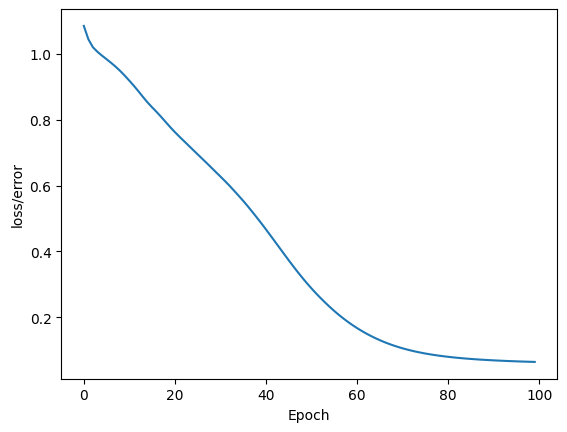

In [18]:
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

# Evaluate

In [19]:
# Evaluate the model on the Test set
with torch.no_grad():
    y_eval = model.forward(X_test)
    loss = criterion(y_eval, y_test)

loss

tensor(0.0634)

In [25]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        if y_test[i] == 0:
            x = "Setosa"
        elif y_test[i] == 1:
            x = "Versicolor"
        else:
            x = "Virginica"

        print(f"{i + 1}.) {str(y_val)} \t {x}")    # tell us what type of Iris the model predicted

        if y_val.argmax().item() == y_test[i]:
            correct += 1

print(f"Correct total: {correct}")

1.) tensor([-1.4120,  6.3132,  2.6088]) 	 Versicolor
2.) tensor([ 8.4023,  2.4573, -7.5391]) 	 Setosa
3.) tensor([-12.1991,   1.1829,  13.7443]) 	 Virginica
4.) tensor([-1.6752,  5.9271,  2.8622]) 	 Versicolor
5.) tensor([-1.5887,  6.7559,  2.8371]) 	 Versicolor
6.) tensor([ 7.8451,  2.3289, -7.0010]) 	 Setosa
7.) tensor([ 1.1273,  6.0707, -0.0493]) 	 Versicolor
8.) tensor([-5.2088,  4.4484,  6.5316]) 	 Virginica
9.) tensor([-3.2614,  4.9128,  4.4788]) 	 Versicolor
10.) tensor([0.5683, 6.5565, 0.5445]) 	 Versicolor
11.) tensor([-4.3492,  4.7780,  5.6344]) 	 Virginica
12.) tensor([ 7.3631,  2.0552, -6.5497]) 	 Setosa
13.) tensor([ 8.1384,  2.3552, -7.2879]) 	 Setosa
14.) tensor([ 7.4936,  2.1057, -6.6740]) 	 Setosa
15.) tensor([ 7.8643,  2.2491, -7.0269]) 	 Setosa
16.) tensor([-1.3322,  6.5325,  2.5448]) 	 Versicolor
17.) tensor([-8.2712,  2.4244,  9.6406]) 	 Virginica
18.) tensor([0.3374, 6.4826, 0.7657]) 	 Versicolor
19.) tensor([-1.5909,  5.7677,  2.7565]) 	 Versicolor
20.) tensor([-

# Save the NN Model

In [26]:
torch.save(model.state_dict(), "hello_iris.pt")

# Load it back in

In [27]:
new_model = Model()
new_model.load_state_dict(torch.load("hello_iris.pt"))

<All keys matched successfully>

In [28]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)